<div style="border: solid green 2px; padding: 20px">

  <b>Overall Summary of the Project – Iteration 2</b><br><br>
  Hello Dylan, congratulations on submitting your project!<br>

  My name is <b>Victor Camargo</b> 
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and I’ll be reviewing your project today.<br>

  <b>What you did well:</b><br>
  ✅ Clear data loading and initial exploration, including duplicates check and column standardization.<br>
  ✅ Thoughtful handling of missing values for high-missing columns and a reasonable justification for keeping year_of_release as nullable integers.<br>
  ✅ Creation of total_sales and thorough genre and regional analyses, with plots and market-share calculations.<br>
  ✅ Completed both hypothesis tests with appropriate test selection and clear conclusions.<br>

  <b>Required fixes (only if red issues exist):</b><br>
  ⛔️ None — all previously reported red issues have been addressed in this iteration.<br>

  <b>Project Status:</b><br>
  <div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
    <b>Approved</b>
  </div>


<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [ ]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [ ]:
# Load the dataset
games = pd.read_csv('/datasets/games.csv')

In [ ]:
# Display basic information about the dataset
games.info()
games.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [ ]:
# Check for duplicate entries
duplicated_games = games.duplicated().sum()
print(duplicated_games)

0


### Key Questions to Answer:
- What's the total number of records in our dataset?

  16715
- What data types are present in each column?

  float and object
- Are there any obvious issues with the data?

  Need to change some types of data and drop some missing values 
- Do we see any immediate patterns or anomalies?

  Games in the 1900's dont have critic score, user score, or ratings.

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [ ]:
# Convert column names to lowercase
games.columns = games.columns.str.lower()

In [ ]:
# Verify the changes
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice work setting up the analysis: you loaded the dataset, inspected structure/types/missingness, checked for duplicates, and standardized the column names. This creates a solid foundation for the rest of the notebook.

</div>


### 2.2 Data Type Conversion

In [ ]:
# Check current data types
games.dtypes

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

In [ ]:
# Make changes to data types if necessary
# Describe the columns where the data types have been changed and why.
# Year of release column needed to be changed to int from float.
games['year_of_release'] = games['year_of_release'].astype('Int64')


# User score needs to be changed to float
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You converted `year_of_release` to an integer type while it still contains missing values. Consider explicitly stating your strategy for these missing years (e.g., drop, impute, or keep as missing) and how that choice will affect any later time-based analysis and plots.

</div>


Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.

-I changed the TBD values to NaN, or missing values, using the coerce argument inside of pd.to_numeric. 

I will drop the missing values in the name and genre column next.

I will leave the missing values in the year_of _release column as NaN values so they can still contribute to the platform, genre, and sales analysis data. Since it is less than 2% of the data it should not have a noticeable effect on the time based analysis.


### 2.3 Handling Missing Values

In [ ]:
# Examine missing values
print(games.isnull().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


In [ ]:
# Calculate percentage of missing values
print(games.isnull().mean())

name               0.000120
platform           0.000000
year_of_release    0.016093
genre              0.000120
na_sales           0.000000
eu_sales           0.000000
jp_sales           0.000000
other_sales        0.000000
critic_score       0.513192
user_score         0.545917
rating             0.404786
dtype: float64


 Analyze patterns in missing values

 Games in the 1900's dont have critic score, user score, or ratings.

In [ ]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy
games.dropna(subset=['genre', 'name'], inplace=True)


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your missing-value handling for `name`/`genre` isn’t applied to the main DataFrame because `dropna(...)` isn’t assigned back to `games` (or performed with `inplace=True`). As a result, later steps still use the unfiltered data.

</div>


Why do you think the values are missing? Give possible reasons.

  The values are missing fro the earlier releases because the critic score, user score,   and rating systems had not yet been created. Or, some games are just too obscure or small to attract critics or users.

  The two titles that don't have a name or genre are most likely older games that were small and obscure so data on them was not tracked very well.

Explain why you filled in the missing values as you did or why you decided to leave them blank.

I left the NaN values blank in the critic score, user score, and rating because there are roughly 9000 missing values, which is more than half of the data. So, if I were to remove or change them it would change the data way too much.



### 2.4 Calculate Total Sales

In [ ]:
# Calculate total sales across all regions and put them in a different column

games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
print(games)
print(games['total_sales'].sum())






                                name platform  year_of_release         genre  \
0                         Wii Sports      Wii             2006        Sports   
1                  Super Mario Bros.      NES             1985      Platform   
2                     Mario Kart Wii      Wii             2008        Racing   
3                  Wii Sports Resort      Wii             2009        Sports   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [ ]:
# Create a DataFrame with game releases by year

games_by_year = games.groupby(['year_of_release']).agg({
    'name':'count'
}).reset_index()

print(games_by_year)

    year_of_release  name
0              1980     9
1              1981    46
2              1982    36
3              1983    17
4              1984    14
5              1985    14
6              1986    21
7              1987    16
8              1988    15
9              1989    17
10             1990    16
11             1991    41
12             1992    43
13             1993    60
14             1994   121
15             1995   219
16             1996   263
17             1997   289
18             1998   379
19             1999   338
20             2000   350
21             2001   482
22             2002   829
23             2003   775
24             2004   762
25             2005   939
26             2006  1006
27             2007  1197
28             2008  1427
29             2009  1426
30             2010  1255
31             2011  1136
32             2012   653
33             2013   544
34             2014   581
35             2015   606
36             2016   502


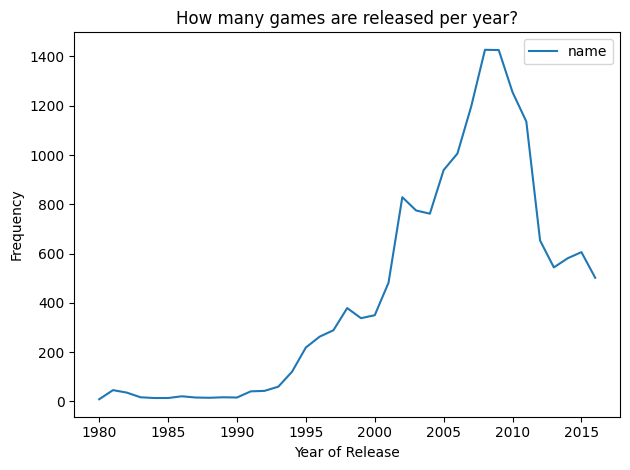

In [ ]:
# Visualize the distribution of games across years

games_by_year.plot(kind='line',
                   title='How many games are released per year?',
                   x='year_of_release',
                   y='name',
                   xlabel='Year of Release',
                   ylabel='Frequency'
)
plt.tight_layout()
plt.show()



    year_of_release  total_sales
0              1980        11.38
1              1981        35.68
2              1982        28.88
3              1983        16.80
4              1984        50.35
5              1985        53.95
6              1986        37.08
7              1987        21.70
8              1988        47.21
9              1989        73.45
10             1990        49.37
11             1991        32.23
12             1992        76.16
13             1993        45.99
14             1994        79.23
15             1995        88.12
16             1996       199.15
17             1997       201.07
18             1998       256.31
19             1999       251.11
20             2000       201.66
21             2001       331.46
22             2002       394.97
23             2003       357.54
24             2004       418.68
25             2005       457.82
26             2006       517.71
27             2007       604.75
28             2008       671.50
29        

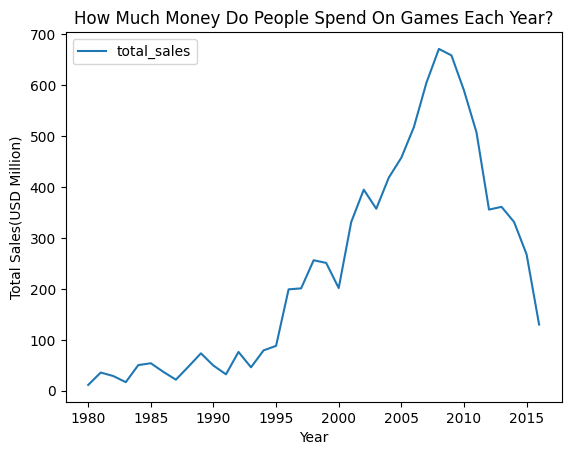

Game release Statistics by :
                     mean  median        std
year_of_release                             
1980             1.264444   0.770   1.383547
1981             0.775652   0.465   0.783019
1982             0.802222   0.540   1.257910
1983             0.988235   0.770   0.838825
1984             3.596429   1.485   7.200795
1985             3.853571   1.015  10.510376
1986             1.765714   1.360   1.328001
1987             1.356250   0.885   1.225174
1988             3.147333   1.510   4.414414
1989             4.320588   1.610   7.895161
1990             3.085625   1.520   4.827705
1991             0.786098   0.380   1.008699
1992             1.771163   0.790   2.469928
1993             0.766500   0.355   1.440388
1994             0.654793   0.270   1.184502
1995             0.402374   0.140   0.760314
1996             0.757224   0.210   2.304625
1997             0.695744   0.280   1.289182
1998             0.676280   0.260   1.250623
1999             0.742929 

In [ ]:
# Display summary statistics for each year
games_by_year.describe()

games_by_year_sales = games.groupby('year_of_release').agg({
    'total_sales':'sum'
}).reset_index()

print(games_by_year_sales)
games_by_year_sales.plot(kind='line',
                        x='year_of_release',
                        y='total_sales',
                        xlabel='Year',
                         ylabel='Total Sales(USD Million)',
                         title='How Much Money Do People Spend On Games Each Year?'
                         
)

plt.show()

games_by_year_stats = games.groupby('year_of_release')['total_sales'].agg(['mean', 'median', 'std'])
print("Game release Statistics by :")
print(games_by_year_stats)

### Questions to Consider:
- Which years show significant numbers of game releases?

  2005-2011
- Are there any notable trends or patterns in the number of releases?

 there was a spike starting in from 1995-2011 and then a major drop after 2011.
- Is there enough recent data to make predictions for 2017?

  Not yet. Though, there is a trend that the total game sales does almost exactly correlate with the amount of game releases per year.

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [ ]:
# Calculate total sales by platform and year
games_by_year_and_platform = games.groupby(['year_of_release', 'platform']).agg({
    'total_sales':'sum'
}).reset_index()
print(games_by_year_and_platform)



     year_of_release platform  total_sales
0               1980     2600        11.38
1               1981     2600        35.68
2               1982     2600        28.88
3               1983     2600         5.84
4               1983      NES        10.96
..               ...      ...          ...
233             2016      PSV         4.25
234             2016      Wii         0.18
235             2016     WiiU         4.60
236             2016     X360         1.52
237             2016     XOne        26.15

[238 rows x 3 columns]


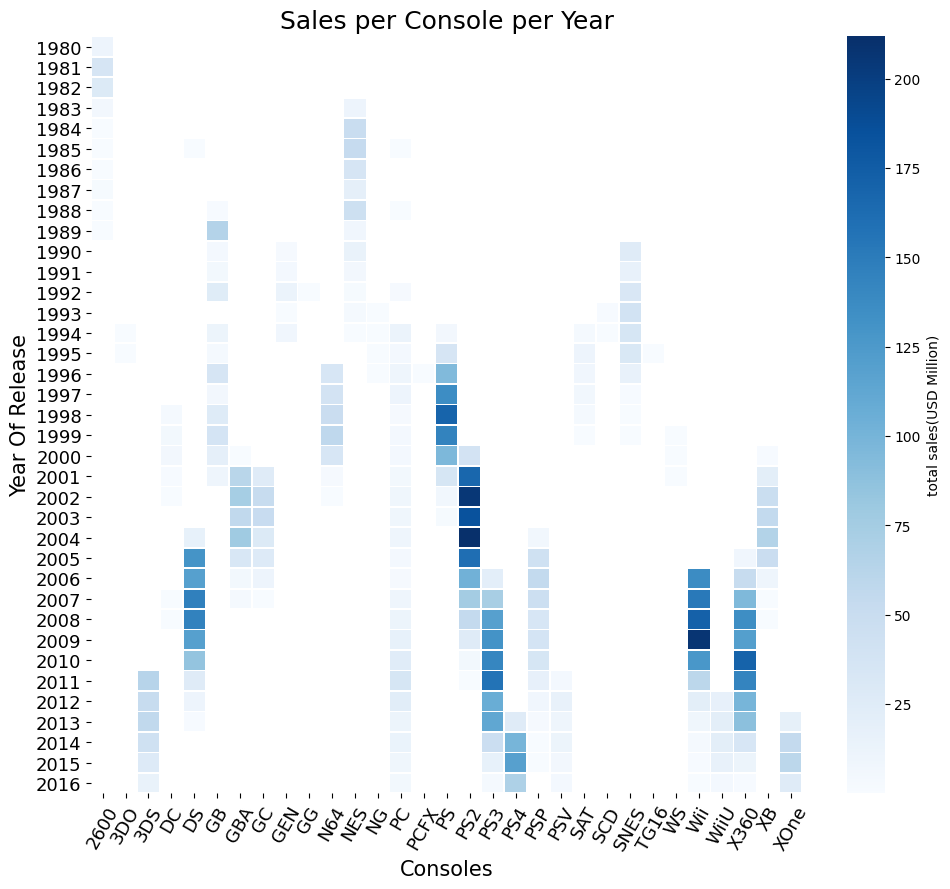

In [ ]:
# Create a heatmap of platform sales over time
pivot_games = games_by_year_and_platform.pivot(
    index='year_of_release',
    columns='platform',
    values='total_sales')


plt.figure(figsize= (10, 9))
sns.heatmap(pivot_games,
           cmap='Blues',
           linewidths=0.5,
           cbar_kws={"label": "total sales(USD Million)"})
plt.title('Sales per Console per Year', fontsize=18)
plt.xticks(rotation=60, ha= 'center', fontsize=13)
plt.yticks(fontsize=13)
plt.ylabel('Year Of Release', fontsize=15)
plt.xlabel('Consoles', fontsize=15)
plt.tight_layout()
plt.show()


Identify platforms with declining sales

In 2016, all of them. They are the PS3, PSV, Wii, WiiU, X360, XOne, and PS4.

In [ ]:
# Show declining sales with .pct_change()
pct_games_by_year_and_platform = games_by_year_and_platform[games_by_year_and_platform['year_of_release'].isin([2015, 2016])]
    



pivot_pct_games_by_year_and_platform = pct_games_by_year_and_platform.pivot_table(index='year_of_release', columns='platform', values='total_sales')
pivot_pct_change_games_by_year_and_platform = pivot_pct_games_by_year_and_platform.pct_change()
print(pivot_pct_change_games_by_year_and_platform)


platform              3DS        PC       PS3       PS4  PSP   PSV       Wii  \
year_of_release                                                                
2015                  NaN       NaN       NaN       NaN  NaN   NaN       NaN   
2016            -0.455004 -0.383803 -0.785969 -0.417578  0.0 -0.32 -0.842105   

platform             WiiU     X360      XOne  
year_of_release                               
2015                  NaN      NaN       NaN  
2016            -0.718654 -0.87291 -0.565181  


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The “declining sales” conclusion needs to be supported with calculations from your platform-by-year totals (e.g., year-over-year comparisons per platform within the chosen period). Listing platforms without showing the trend makes the claim hard to verify.

</div>


### Questions to Consider:
- Which platforms show consistent sales over time?

  PC, then playstation consoles(PS, PS2, PS3, PS4, PSP, PSV), then most nintendo consoles(GB, DS, 3DS, WII), and finally Xbox(XB, X360, XOne).
- Can you identify platforms that have disappeared from the market?

The Platforms that have zero sales from 2013-2016 are:
  2600, 3DO, DC, GB, GBA, GC, GEN, GG, N64, NES, NG, PCFX, PS, PS2, SAT, SCD, SNES, T16, WS, and XB.
- What's the typical lifecycle of a gaming platform?

  They get about 1-2 years of exponentioal growth before their 5 years of peak sales, then they gradually and linerally decline and eventually stop making money after another 1-4 years in corelation with how how high their sales were.

In [ ]:

games_zero = ['2600', '3DO', 'DC', 'GB', 'GBA', 'GC', 'GEN', 'GG', 'N64', 'NES', 'NG', 'PCFX', 'PS', 'PS2', 'SAT', 'SCD', 'SNES', 'T16', 'WS', 'XB']

year_zero = [2013, 2014, 2015, 2016]
games_zero_sales = games_by_year_and_platform[games_by_year_and_platform['platform'].isin(games_zero)].copy()
games_zero_sales_2016 = games_zero_sales[games_zero_sales['year_of_release'].isin(year_zero)].copy()
print(games_zero_sales_2016)


Empty DataFrame
Columns: [year_of_release, platform, total_sales]
Index: []


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

It would be clearer to define what “disappeared from the market” means in your analysis (for example: platforms with zero sales in the most recent year(s) you’re using). Then identify them directly from the platform-by-year sales table so the list matches the data.

</div>


## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

                                name platform  year_of_release         genre  \
16                Grand Theft Auto V      PS3             2013        Action   
23                Grand Theft Auto V     X360             2013        Action   
31         Call of Duty: Black Ops 3      PS4             2015       Shooter   
33               Pokemon X/Pokemon Y      3DS             2013  Role-Playing   
42                Grand Theft Auto V      PS4             2014        Action   
...                              ...      ...              ...           ...   
16703               Strawberry Nauts      PSV             2016     Adventure   
16707               Aiyoku no Eustia      PSV             2014          Misc   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

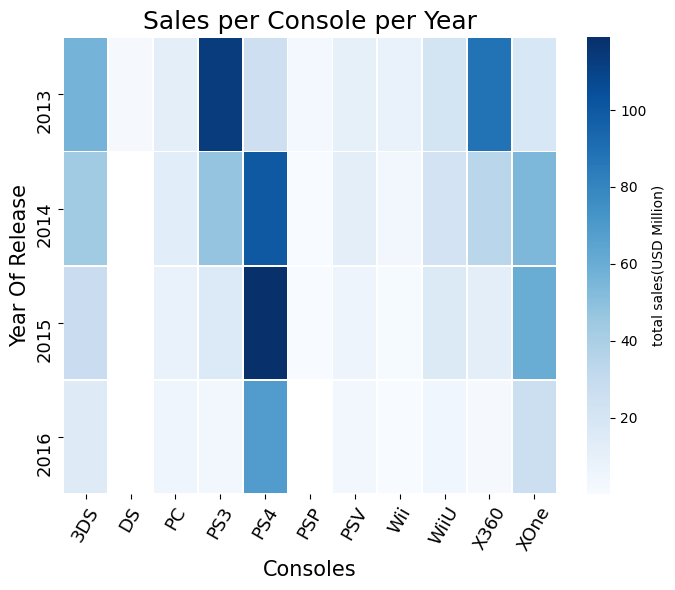

In [ ]:
# Your code here to filter the dataset to relevant years
# Example:
relevant_years = [2013, 2014, 2015, 2016]
games_relevant = games[games['year_of_release'].isin(relevant_years)].copy()
print(games_relevant)
# Justify your choice with data
games_relevant_by_year_and_platform = games_relevant.groupby(['year_of_release', 'platform']).agg({
    'total_sales':'sum'
}).reset_index()
pivot_games = games_relevant_by_year_and_platform.pivot(
    index='year_of_release',
    columns='platform',
    values='total_sales')
print(pivot_games)

plt.figure(figsize= (7,6))
sns.heatmap(pivot_games,
           cmap='Blues',
           linewidths=0.5,
           cbar_kws={"label": "total sales(USD Million)"})
plt.title('Sales per Console per Year', fontsize=18)
plt.xticks(rotation=60, ha= 'center', fontsize=13)
plt.yticks(fontsize=13)
plt.ylabel('Year Of Release', fontsize=15)
plt.xlabel('Consoles', fontsize=15)
plt.tight_layout()
plt.show()


### Document Your Decision:
- What years did you select and why?

  2013-2016. This is when the PS4 and Xbox One launched and when the 3ds is still relevant, which will be the main selling consoles going into 2017.
- How does this period reflect current market conditions?

    It doesn't include the peak of the previous generation but instead theirfinal decline and also the ushering in of the new gneration. 
  
- What factors influenced your decision?

  Release of Xbox one and PS4. Also, the decline of the previous generation of platforms such as the Wii, Xbox 360, PS3, and DS. 

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [ ]:
# Analyze platform sales trends
games_relevant_sales = games_relevant.groupby('platform').agg({
    'total_sales':'sum'
}).reset_index()
print(games_relevant_sales)

games_relevant_sales_yearly = games_relevant.groupby(['platform','year_of_release']).agg({
    'total_sales':'sum'
}).reset_index()
print(games_relevant_sales_yearly)

   platform  total_sales
0       3DS       143.25
1        DS         1.54
2        PC        39.43
3       PS3       181.43
4       PS4       314.14
5       PSP         3.50
6       PSV        32.99
7       Wii        13.66
8      WiiU        64.63
9      X360       136.80
10     XOne       159.32
   platform  year_of_release  total_sales
0       3DS             2013        56.57
1       3DS             2014        43.76
2       3DS             2015        27.78
3       3DS             2016        15.14
4        DS             2013         1.54
5        PC             2013        12.38
6        PC             2014        13.28
7        PC             2015         8.52
8        PC             2016         5.25
9       PS3             2013       113.25
10      PS3             2014        47.76
11      PS3             2015        16.82
12      PS3             2016         3.60
13      PS4             2013        25.99
14      PS4             2014       100.00
15      PS4             2015

In [ ]:
# Sort platforms by total sales

sorted_games_relevant_sales = games_relevant_sales.sort_values('total_sales', ascending=False)
print(sorted_games_relevant_sales)


   platform  total_sales
4       PS4       314.14
3       PS3       181.43
10     XOne       159.32
0       3DS       143.25
9      X360       136.80
8      WiiU        64.63
2        PC        39.43
6       PSV        32.99
7       Wii        13.66
5       PSP         3.50
1        DS         1.54


   platform  total_sales
4       PS4       314.14
3       PS3       181.43
10     XOne       159.32
0       3DS       143.25
9      X360       136.80


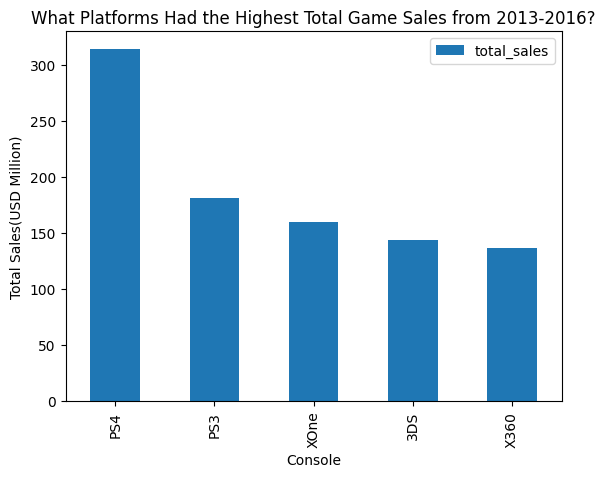

   platform  year_of_release  total_sales
0       3DS             2013        56.57
1       3DS             2014        43.76
2       3DS             2015        27.78
3       3DS             2016        15.14
9       PS3             2013       113.25
10      PS3             2014        47.76
11      PS3             2015        16.82
12      PS3             2016         3.60
13      PS4             2013        25.99
14      PS4             2014       100.00
15      PS4             2015       118.90
16      PS4             2016        69.25
32     X360             2013        88.58
33     X360             2014        34.74
34     X360             2015        11.96
35     X360             2016         1.52
36     XOne             2013        18.96
37     XOne             2014        54.07
38     XOne             2015        60.14
39     XOne             2016        26.15


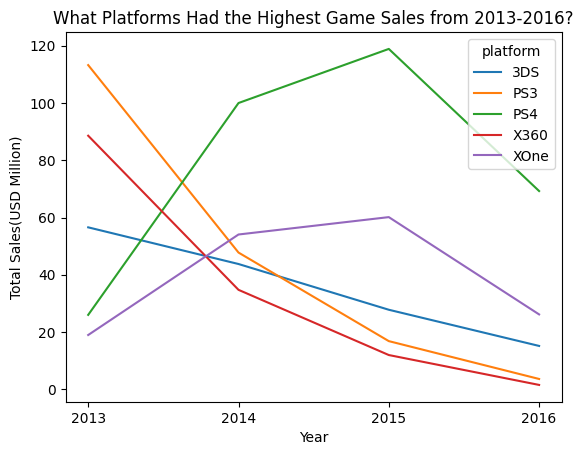

platform              3DS       PS3       PS4      X360      XOne
year_of_release                                                  
2013                  NaN       NaN       NaN       NaN       NaN
2014            -0.226445 -0.578278  2.847634 -0.607812  1.851793
2015            -0.365174 -0.647822  0.189000 -0.655728  0.112262
2016            -0.455004 -0.785969 -0.417578 -0.872910 -0.565181


<Figure size 100x100 with 0 Axes>

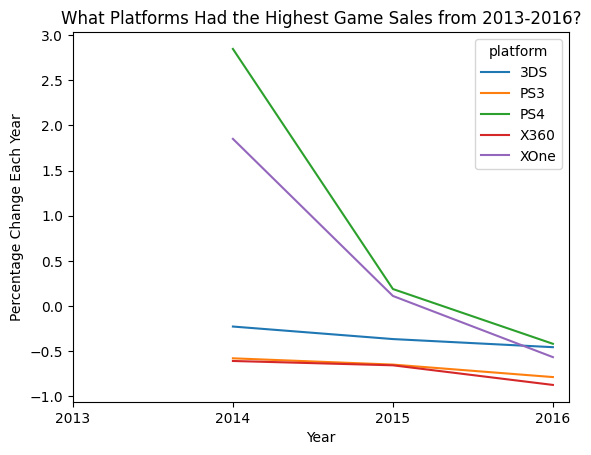

In [ ]:
# Visualize top platforms
top_platforms = ['PS4', 'PS3', 'XOne', '3DS', 'X360']
top_platform_sorted_games_relevant_sales = sorted_games_relevant_sales[sorted_games_relevant_sales['platform'].isin(top_platforms)]
print(top_platform_sorted_games_relevant_sales)

top_platform_sorted_games_relevant_sales.plot(kind='bar',
                                              title= 'What Platforms Had the Highest Total Game Sales from 2013-2016?',
                                              x='platform',
                                              y='total_sales',
                                              xlabel='Console',
                                              ylabel='Total Sales(USD Million)'
     )
plt.show()


# Calculate year-over-year growth for each platform

yearly_games_relevant_sales = games_relevant.groupby(['platform', 'year_of_release']).agg({
    'total_sales':'sum'
}).reset_index()

yearly_top_platform_sorted_games_relevant_sales = yearly_games_relevant_sales[yearly_games_relevant_sales['platform'].isin(top_platforms)].copy()
print(yearly_top_platform_sorted_games_relevant_sales)

yearly_top_platform_sorted_games_relevant_sales.pivot(
    index='year_of_release', columns='platform', values='total_sales').plot(kind='line',
                                                                            xlabel='Year',
                                                                            ylabel='Total Sales(USD Million)',
                                                                            title='What Platforms Had the Highest Game Sales from 2013-2016?'
                                                                           )
years = yearly_top_platform_sorted_games_relevant_sales['year_of_release'].unique()
plt.xticks(sorted(years))
                                              
plt.show()




# Your code here to calculate and visualize platform growth rates
yearly_top_platform_sorted_games_relevant_sales = yearly_games_relevant_sales[yearly_games_relevant_sales['platform'].isin(top_platforms)].copy()



pivot_yearly_top_platform_sorted_games_relevant_sales = yearly_top_platform_sorted_games_relevant_sales.pivot_table(
    index='year_of_release', columns='platform', values='total_sales')

yearly_top_platform_sorted_games_relevant_sales_pct_change = pivot_yearly_top_platform_sorted_games_relevant_sales.pct_change()
print(yearly_top_platform_sorted_games_relevant_sales_pct_change)

plt.figure(figsize=(1,1))
yearly_top_platform_sorted_games_relevant_sales_pct_change.plot(kind='line',
                                                     xlabel='Year',
                                                     ylabel='Percentage Change Each Year',
                                                     title='What Platforms Had the Highest Game Sales from 2013-2016?'
                                                                           )
years = yearly_top_platform_sorted_games_relevant_sales['year_of_release'].unique()
plt.xticks(sorted(years))
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your year-over-year % change series is created with `pct_change()`, but the result isn’t reliably aligned back to the same rows of your DataFrame, which can shift/misassign growth rates in the plot. Consider calculating % change on a pivot table (years as index, platforms as columns) and plotting that output.

</div>


## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

Text(0, 0.5, 'Total Sales(USD Million)')

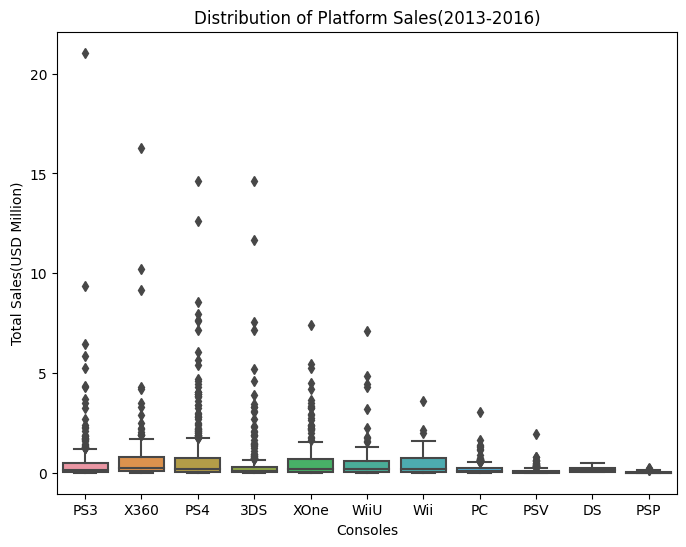

In [ ]:
# Create box plot of sales by platform
plt.figure(figsize=(8, 6))

sns.boxplot(data=games_relevant, x='platform', y='total_sales')
plt.title('Distribution of Platform Sales(2013-2016)')
plt.xlabel('Consoles')
plt.ylabel('Total Sales(USD Million)')

In [ ]:
# Calculate detailed statistics for each platform
games_relevant.describe()
games_relevant_stats = games_relevant.groupby('platform')['total_sales'].agg(['mean', 'var', 'std'])
print("Game Sales Statistics by Platform:")
print(games_relevant_stats)


Game Sales Statistics by Platform:
              mean       var       std
platform                              
3DS       0.472772  1.908119  1.381347
DS        0.192500  0.029593  0.172026
PC        0.208624  0.124118  0.352304
PS3       0.525884  2.108128  1.451939
PS4       0.801378  2.590350  1.609456
PSP       0.052239  0.003572  0.059768
PSV       0.092151  0.023660  0.153816
Wii       0.593913  0.838016  0.915432
WiiU      0.562000  1.079060  1.038778
X360      0.735484  2.766484  1.663275
XOne      0.645020  1.073584  1.036139


## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [ ]:
# Choose a popular platform based on your previous analysis

reviews_games_relevant = games_relevant.groupby(['platform', 'year_of_release', 'name']).agg({
    'critic_score':'mean',
    'user_score':'mean',
    'total_sales':'sum'
}).reset_index()

NaN_reviews_games_relevant= reviews_games_relevant.dropna()

NaN_reviews_games_relevant_3ds_mask = NaN_reviews_games_relevant['platform']=='3DS'
NaN_reviews_games_relevant_3ds = NaN_reviews_games_relevant[NaN_reviews_games_relevant_3ds_mask]
print(NaN_reviews_games_relevant_3ds)


    platform  year_of_release                                        name  \
4        3DS             2013         Attack on Titan: Humanity in Chains   
5        3DS             2013            Batman: Arkham Origins Blackgate   
8        3DS             2013                          Beyblade Evolution   
13       3DS             2013  Conception II: Children of the Seven Stars   
19       3DS             2013                        Disney Magical World   
..       ...              ...                                         ...   
281      3DS             2016                      Mario Party: Star Rush   
283      3DS             2016                  Mega Man Legacy Collection   
284      3DS             2016             Metroid Prime: Federation Force   
299      3DS             2016                                    Terraria   
302      3DS             2016              Zero Escape: Zero Time Dilemma   

     critic_score  user_score  total_sales  
4            46.0         4.5 

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

To analyze how reviews affect sales for a single platform, avoid aggregating to one row per year (it leaves only 4 observations). Use game-level rows for the chosen platform (one point per game) before building scatter plots/correlations.

</div>


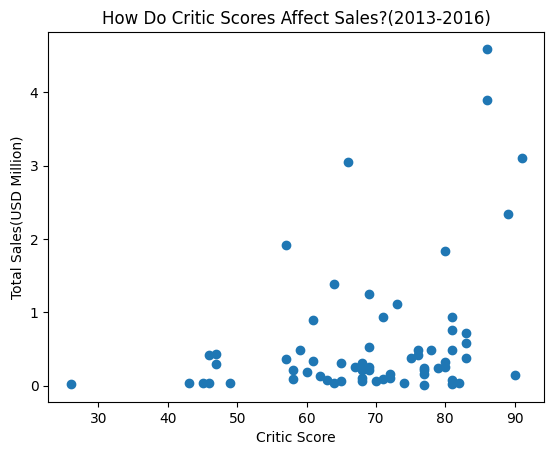

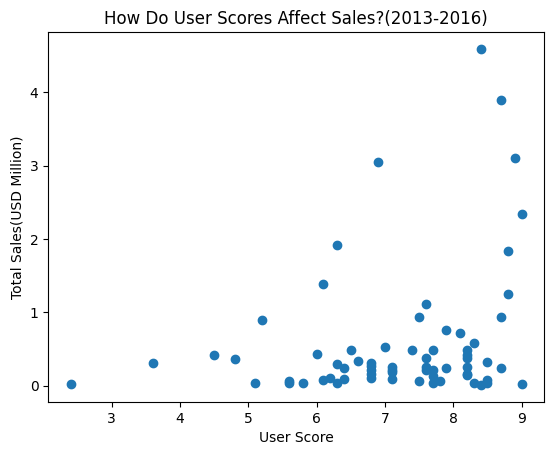

In [ ]:
# Create scatter plots for both critic and user scores
plt.scatter(x=NaN_reviews_games_relevant_3ds['critic_score'], y=NaN_reviews_games_relevant_3ds['total_sales'])
plt.xlabel('Critic Score')
plt.ylabel('Total Sales(USD Million)')
plt.title('How Do Critic Scores Affect Sales?(2013-2016)')
plt.show()

plt.scatter(x=NaN_reviews_games_relevant_3ds['user_score'], y=NaN_reviews_games_relevant_3ds['total_sales'])
plt.xlabel('User Score')
plt.ylabel('Total Sales(USD Million)')
plt.title('How Do User Scores Affect Sales?(2013-2016)')
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

These scatter plots are based on the yearly-aggregated table, which can be misleading due to the small number of points. Also, the second plot’s title mentions “Critic Scores” even though it uses user scores—consider adjusting titles/labels so the interpretation is unambiguous.

</div>


In [ ]:
# Critic Scores
correlation, p_value = st.pearsonr(x=NaN_reviews_games_relevant_3ds['critic_score'], y=NaN_reviews_games_relevant_3ds['total_sales'])

print("Critic Score Correlation:")
print(correlation)


# User Scores
correlation, p_value = st.pearsonr(x=NaN_reviews_games_relevant_3ds['user_score'], y=NaN_reviews_games_relevant_3ds['total_sales'])

print("User Score Correlation:")
print(correlation)


# Calculate correlations


Critic Score Correlation:
0.33923492878531486
User Score Correlation:
0.2729904366942444


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Pearson correlation here is computed on only 4 aggregated observations, so it’s unlikely to be statistically meaningful. Also, make sure you remove rows with missing scores before running `pearsonr` and report the sample size used so the result is interpretable and reproducible.

</div>


Evaluation

The correlations are 0.34 and 0.27 so not very strong and therefore we must conclude that there is no correlation between sales and critic or user scores.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

This section needs a short written interpretation of your review-vs-sales analysis for the chosen platform (what the scatter/correlation suggest, and any limitations such as missing data or weak relationship).

</div>


## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [ ]:
# Find games released on multiple platforms
games_relevant_cross = games_relevant[games_relevant['name'].duplicated(keep=False)]
print(games_relevant_cross)


                                                name platform  \
16                                Grand Theft Auto V      PS3   
23                                Grand Theft Auto V     X360   
31                         Call of Duty: Black Ops 3      PS4   
42                                Grand Theft Auto V      PS4   
60                              Call of Duty: Ghosts     X360   
...                                              ...      ...   
16672  Metal Gear Solid V: The Definitive Experience     XOne   
16691                   Dynasty Warriors: Eiketsuden      PS3   
16692              Metal Gear Solid V: Ground Zeroes       PC   
16710                  Samurai Warriors: Sanada Maru      PS3   
16714                            Winning Post 8 2016      PSV   

       year_of_release       genre  na_sales  eu_sales  jp_sales  other_sales  \
16                2013      Action      7.02      9.09      0.98         3.96   
23                2013      Action      9.66      5.14   

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You identified multi-platform games, but the section still needs a clear takeaway from the comparison (e.g., which platforms tend to sell more for the same titles, and what pattern you observe). Add a brief summary tied to your table/plot results.

</div>


                                     name platform  total_sales
482                    Grand Theft Auto V      PS3        21.05
484                    Grand Theft Auto V     X360        16.27
174             Call of Duty: Black Ops 3      PS4        14.63
483                    Grand Theft Auto V      PS4        12.62
181                  Call of Duty: Ghosts     X360        10.24
178                  Call of Duty: Ghosts      PS3         9.36
744                             Minecraft     X360         9.18
407                               FIFA 16      PS4         8.58
1146         Star Wars Battlefront (2015)      PS4         7.98
169        Call of Duty: Advanced Warfare      PS4         7.66
412                               FIFA 17      PS4         7.60
1165  Super Smash Bros. for Wii U and 3DS      3DS         7.55
176             Call of Duty: Black Ops 3     XOne         7.39
416                             Fallout 4      PS4         7.17
                                     nam

<Figure size 1500x1000 with 0 Axes>

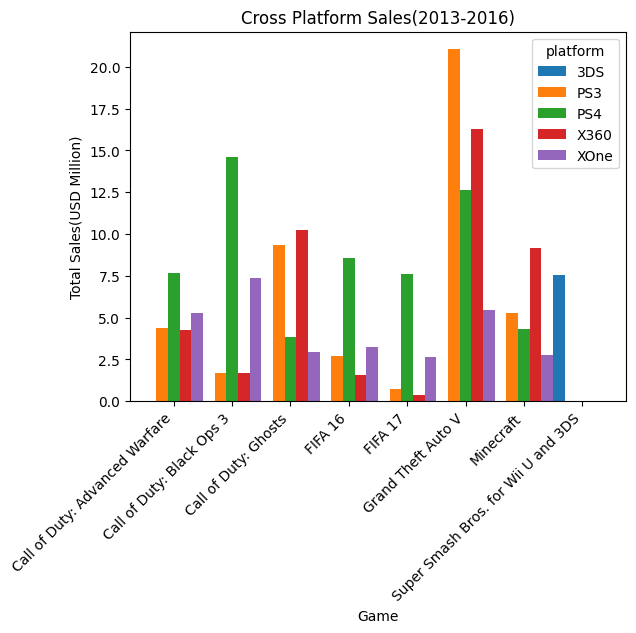

In [ ]:
# Compare sales across platforms for these games
games_relevant_cross_platform = games_relevant_cross.groupby(['name','platform']).agg({
    'total_sales':'sum'
}).reset_index()
top10_cross_platform = ['Grand Theft Auto V', 'Call of Duty: Black Ops 3', 'Call of Duty: Ghosts', 'Minecraft', 'FIFA 16', 'Call of Duty: Advanced Warfare', 'FIFA 17', 'Super Smash Bros. for Wii U and 3DS']
games_relevant_cross_platform = games_relevant_cross_platform.sort_values('total_sales', ascending=False)
print(games_relevant_cross_platform.head(14))
top_games_relevant_cross_platform = games_relevant_cross_platform[games_relevant_cross_platform['name'].isin(top10_cross_platform)]
top_top_games_relevant_cross_platform = top_games_relevant_cross_platform[top_games_relevant_cross_platform['platform'].isin(top_platforms)]
print(top_top_games_relevant_cross_platform)
# Your code here to analyze and visualize cross-platform performance
plt.figure(figsize=(15,10))
top_top_games_relevant_cross_platform.pivot(
    index='name', columns='platform', values='total_sales').plot(kind='bar',
                                     xlabel='Game',
                                     title='Cross Platform Sales(2013-2016)',
                                     ylabel='Total Sales(USD Million)',
                                     width=1)
plt.xticks(rotation=45, ha='right')
plt.show()


As a platform ages it tends to have higher sales in cross platform games it orgionally came out with, as seen with the ps3 and x360 with games like Grand Theft Auto V. However, newer games favor their newer generation conterparts like FIFA 17. Also, on average playstation consoles have the highest cross platform games sales.

## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [ ]:
# Analyze genre performance
games_relevant_genre_year = games_relevant.groupby(['genre', 'year_of_release']).agg({
    'total_sales':'sum',
    'name':'count'
}).reset_index()

games_relevant_genre_year['avg_sales'] = games_relevant_genre_year['total_sales']/games_relevant_genre_year['name']
print(games_relevant_genre_year)
games_relevant_genre = games_relevant.groupby('genre').agg({
    'total_sales':'sum',
    'name':'count'
}).reset_index()
games_relevant_genre['avg_sales'] = games_relevant_genre['total_sales']/games_relevant_genre['name']
print('Total Sales per Genre:')
print(games_relevant_genre)

           genre  year_of_release  total_sales  name  avg_sales
0         Action             2013       122.51   147   0.833401
1         Action             2014        97.23   188   0.517181
2         Action             2015        72.02   253   0.284664
3         Action             2016        30.11   178   0.169157
4      Adventure             2013         6.09    60   0.101500
5      Adventure             2014         5.57    75   0.074267
6      Adventure             2015         8.16    54   0.151111
7      Adventure             2016         3.82    56   0.068214
8       Fighting             2013         7.09    20   0.354500
9       Fighting             2014        15.85    23   0.689130
10      Fighting             2015         7.90    21   0.376190
11      Fighting             2016         4.47    16   0.279375
12          Misc             2013        25.27    42   0.601667
13          Misc             2014        23.38    42   0.556667
14          Misc             2015       

           genre  total_sales  name  avg_sales
0         Action       321.87   766   0.420196
8        Shooter       232.98   187   1.245882
10        Sports       150.65   214   0.703972
7   Role-Playing       145.89   292   0.499623
3           Misc        62.82   155   0.405290
4       Platform        42.63    74   0.576081
6         Racing        39.89    85   0.469294
2       Fighting        35.31    80   0.441375
1      Adventure        23.64   245   0.096490
9     Simulation        21.76    62   0.350968
11      Strategy        10.08    56   0.180000
5         Puzzle         3.17    17   0.186471


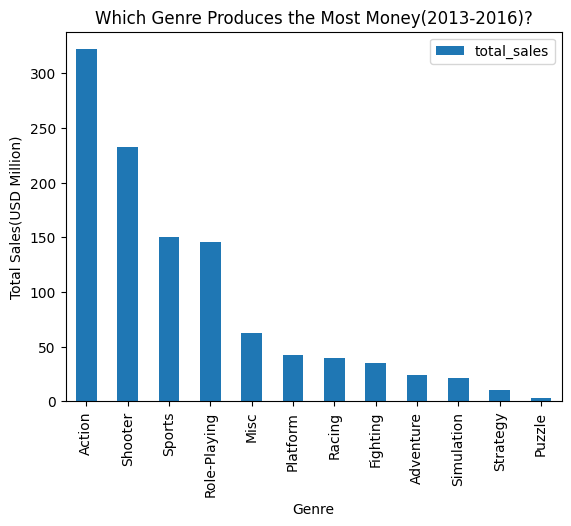

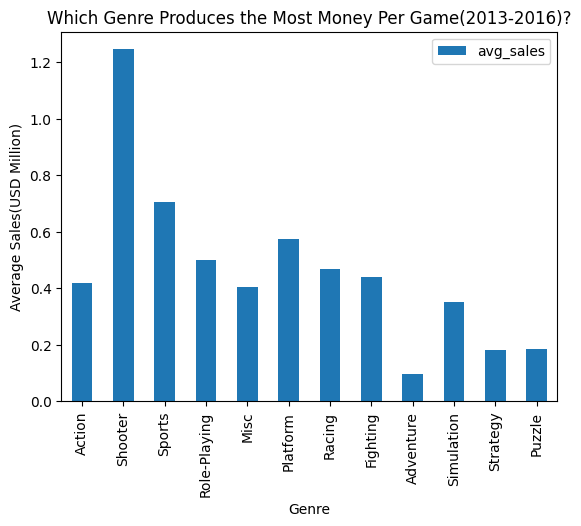

In [ ]:
# Sort genres by total sales
games_relevant_genre_sorted = games_relevant_genre.sort_values('total_sales', ascending=False)
print(games_relevant_genre_sorted)

games_relevant_genre_sorted.plot(kind='bar',
                                title='Which Genre Produces the Most Money(2013-2016)?',
                                x='genre',
                                y='total_sales',
                                xlabel='Genre',
                                ylabel='Total Sales(USD Million)'
)
plt.show()

games_relevant_genre_sorted.plot(kind='bar',
                                title='Which Genre Produces the Most Money Per Game(2013-2016)?',
                                x='genre',
                                y='avg_sales',
                                xlabel='Genre',
                                ylabel='Average Sales(USD Million)'
)
plt.show()


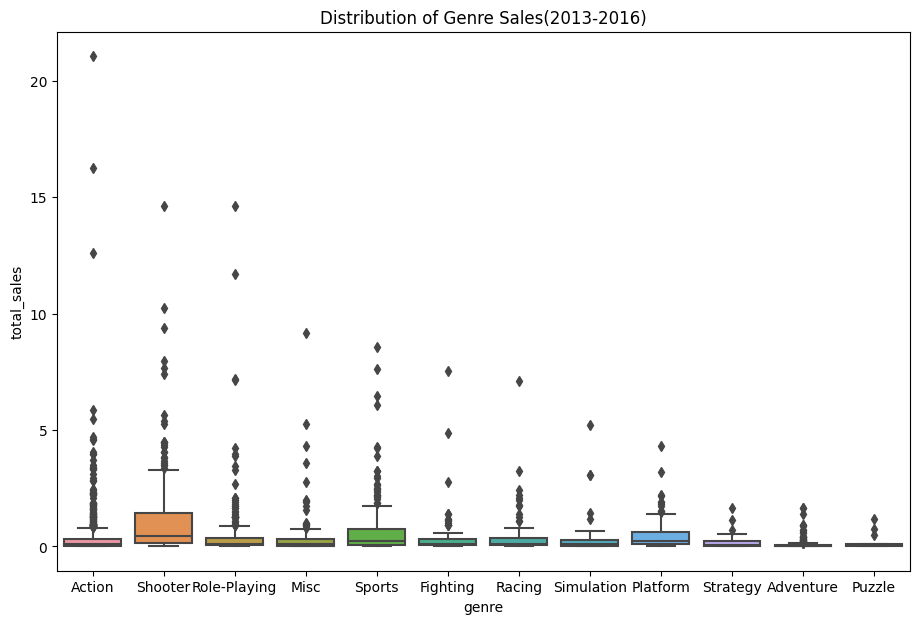

In [ ]:
# Visualize genre distribution
plt.figure(figsize=(11, 7))
sns.boxplot(data=games_relevant, x='genre', y='total_sales')
plt.title('Distribution of Genre Sales(2013-2016)')
plt.show()




           genre  total_sales  name  avg_sales  market_share
0         Action       321.87   766   0.420196     29.510677
8        Shooter       232.98   187   1.245882     21.360790
10        Sports       150.65   214   0.703972     13.812357
7   Role-Playing       145.89   292   0.499623     13.375936
3           Misc        62.82   155   0.405290      5.759657
4       Platform        42.63    74   0.576081      3.908535
6         Racing        39.89    85   0.469294      3.657318
2       Fighting        35.31    80   0.441375      3.237400
1      Adventure        23.64   245   0.096490      2.167435
9     Simulation        21.76    62   0.350968      1.995067
11      Strategy        10.08    56   0.180000      0.924186
5         Puzzle         3.17    17   0.186471      0.290642


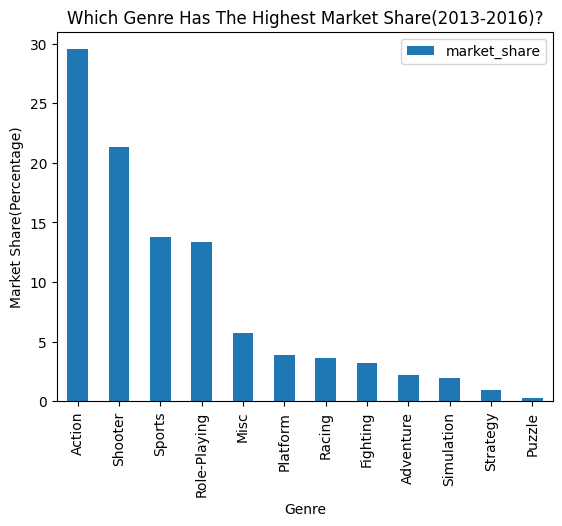

In [ ]:
# Calculate market share for each genre
games_relevant_genre_sorted['market_share'] = games_relevant_genre_sorted['total_sales']/games_relevant_genre_sorted['total_sales'].sum()*100
print(games_relevant_genre_sorted)
games_relevant_genre_sorted.plot(kind='bar',
                                title='Which Genre Has The Highest Market Share(2013-2016)?',
                                x='genre',
                                y='market_share',
                                xlabel='Genre',
                                ylabel='Market Share(Percentage)'
)
plt.show()

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Strong genre analysis: you computed total sales, counts, average sales per game, and market share, and you combined aggregate views with distribution plots (boxplots). This is a well-structured approach for comparing genre performance.

</div>


### Key Questions for Genre Analysis:
- Which genres consistently perform well?

    Action, Shooter, Sports, and Role Playing consistently out perform the other genres.
- Are there any genres showing recent growth or decline?

    They all had a drop in 2016 that goes along with the drop in total sales and releases.
- How does the average performance vary across genres?

    There is a large difference from the total performance with Shooter, Sports, and Platform Games leading the way and action games actually being below average.
    

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [ ]:
# Function to analyze platform performance by region

region_name = 'North America','NA', 'Europe', 'EU', 'Japan', 'JP'

def platform_region_sales(region_name):
    if region_name == 'North America' or region_name == 'NA':
        sort_na_total_sales = games_relevant.groupby('platform').agg({
            'na_sales':'sum'
        }).reset_index().sort_values('na_sales', ascending=False)
        top_na_platforms = sort_na_total_sales.head(5)['platform']
        top_sort_na_total_sales = sort_na_total_sales[sort_na_total_sales['platform'].isin(top_na_platforms)].copy()
        
        top_sort_na_total_sales['na_market_share'] = top_sort_na_total_sales['na_sales']/sort_na_total_sales['na_sales'].sum()*100
        

        return (top_sort_na_total_sales)
              

    elif region_name == 'Europe' or region_name == 'EU':
        sort_eu_total_sales = games_relevant.groupby('platform').agg({
            'eu_sales':'sum'
        }).reset_index().sort_values('eu_sales', ascending=False)
        top_eu_platforms = sort_eu_total_sales.head(5)['platform']
        top_sort_eu_total_sales = sort_eu_total_sales[sort_eu_total_sales['platform'].isin(top_eu_platforms)].copy()
        
        top_sort_eu_total_sales['eu_market_share'] = top_sort_eu_total_sales['eu_sales']/sort_eu_total_sales['eu_sales'].sum()*100
        

        return (top_sort_eu_total_sales)

    elif region_name == 'Japan' or region_name == 'JP':
        sort_jp_total_sales = games_relevant.groupby('platform').agg({
            'jp_sales':'sum'
        }).reset_index().sort_values('jp_sales', ascending=False)
        top_jp_platforms = sort_jp_total_sales.head(5)['platform']
        top_sort_jp_total_sales = sort_jp_total_sales[sort_jp_total_sales['platform'].isin(top_jp_platforms)].copy()
        
        top_sort_jp_total_sales['jp_market_share'] = top_sort_jp_total_sales['jp_sales']/sort_jp_total_sales['jp_sales'].sum()*100
        

        return (top_sort_jp_total_sales)
    else:
        return ('No Data For that Region')

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

For the regional platform analysis, the requirement is to show the top 5 platforms per region (and ideally their market shares). Consider sorting regional totals, selecting the top five, and presenting them in a compact table for easier comparison.

</div>


North America Platform Sales:
   platform  na_sales  na_market_share
4       PS4    108.74        24.842933
10     XOne     93.12        21.274360
9      X360     81.66        18.656188
3       PS3     63.50        14.507322
0       3DS     38.20         8.727239


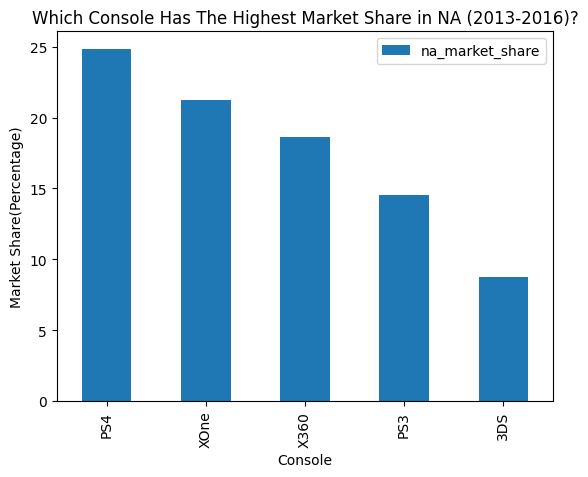

Europe Platform Sales:
   platform  eu_sales  eu_market_share
4       PS4    141.09        35.971241
3       PS3     67.81        17.288326
10     XOne     51.59        13.152997
9      X360     42.52        10.840578
0       3DS     30.96         7.893328


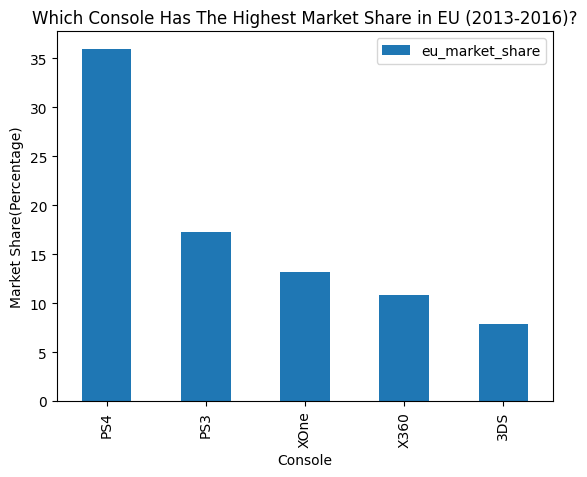

Japan Platform Sales:
  platform  jp_sales  jp_market_share
0      3DS     67.81        48.167353
3      PS3     23.35        16.586163
6      PSV     18.59        13.205001
4      PS4     15.96        11.336838
8     WiiU     10.88         7.728371


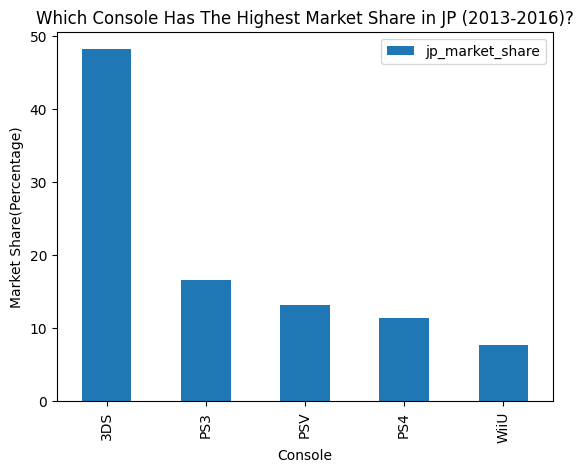

In [ ]:
# Analyze each region
print('North America Platform Sales:')
print(platform_region_sales('NA'))

platform_region_sales('NA').plot(kind='bar',
                                title='Which Console Has The Highest Market Share in NA (2013-2016)?',
                                x='platform',
                                y='na_market_share',
                                xlabel='Console',
                                ylabel='Market Share(Percentage)'
 )
plt.show()

print('Europe Platform Sales:')
print(platform_region_sales('EU'))

platform_region_sales('EU').plot(kind='bar',
                                title='Which Console Has The Highest Market Share in EU (2013-2016)?',
                                x='platform',
                                y='eu_market_share',
                                xlabel='Console',
                                ylabel='Market Share(Percentage)'
        )
plt.show()

print('Japan Platform Sales:')
print(platform_region_sales('JP'))
platform_region_sales('JP').plot(kind='bar',
                                title='Which Console Has The Highest Market Share in JP (2013-2016)?',
                                x='platform',
                                y='jp_market_share',
                                xlabel='Console',
                                ylabel='Market Share(Percentage)'
        )
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The extra “None” in the output appears because the function prints the table but doesn’t return it. Consider returning the computed result and printing outside the function to keep outputs clean and predictable. (Recurring requirement reminder: also limit results to the top 5 platforms per region and include market shares.)

</div>


### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [ ]:
# Create a comparative platform analysis

na_table = platform_region_sales('NA')
eu_table = platform_region_sales('EU')
jp_table = platform_region_sales('JP')


regional_platform_data = na_table.merge(eu_table, on='platform', how='outer')

regional_platform_data = regional_platform_data.merge(jp_table, on='platform', how='outer')

print(regional_platform_data)







  platform  na_sales  na_market_share  eu_sales  eu_market_share  jp_sales  \
0      PS4    108.74        24.842933    141.09        35.971241     15.96   
1     XOne     93.12        21.274360     51.59        13.152997       NaN   
2     X360     81.66        18.656188     42.52        10.840578       NaN   
3      PS3     63.50        14.507322     67.81        17.288326     23.35   
4      3DS     38.20         8.727239     30.96         7.893328     67.81   
5      PSV       NaN              NaN       NaN              NaN     18.59   
6     WiiU       NaN              NaN       NaN              NaN     10.88   

   jp_market_share  
0        11.336838  
1              NaN  
2              NaN  
3        16.586163  
4        48.167353  
5        13.205001  
6         7.728371  


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your NA/EU/JP totals by platform are useful, but the intended comparison is based on each region’s top 5 platforms and how their market shares differ across regions. Consider computing top-5-by-region tables and comparing shares (not only raw totals).

</div>


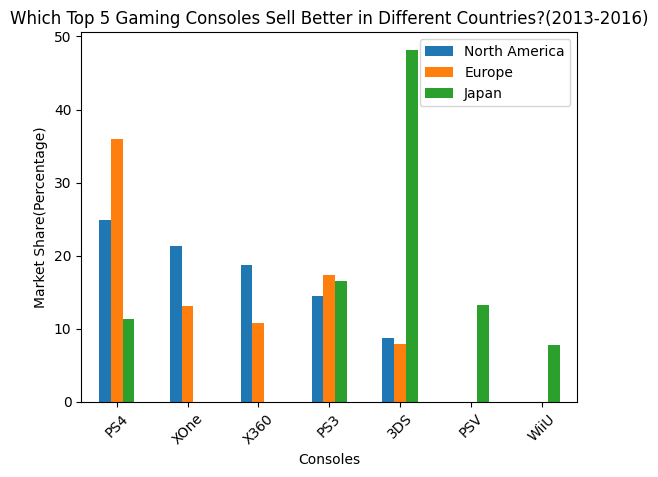

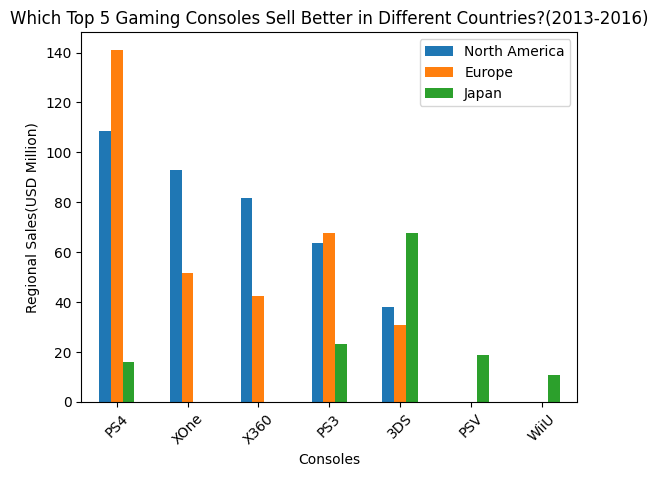

In [ ]:
# Visualize cross-regional comparison for top platforms
regional_platform_data.plot(kind='bar',
                   y=['na_market_share', 'eu_market_share', 'jp_market_share'],
                   x= 'platform',
                xlabel='Consoles',
                ylabel='Market Share(Percentage)',
                rot=45,
                title='Which Top 5 Gaming Consoles Sell Better in Different Countries?(2013-2016)',
               )
plt.legend(['North America', 'Europe', 'Japan'])
plt.show()

regional_platform_data.plot(kind='bar',

                   y=['na_sales', 'eu_sales', 'jp_sales'],
                   x= 'platform',
                xlabel='Consoles',
                ylabel='Regional Sales(USD Million)',
                rot=45,
                title='Which Top 5 Gaming Consoles Sell Better in Different Countries?(2013-2016)',
               )
plt.legend(['North America', 'Europe', 'Japan'])
plt.show()



Japan seems to prefer handheld consoles like the 3ds, PSV, and WiiU, while Europe tends to prefer playstation consoles. North America on the other hand has a much more diverse preference pool but with the PS4 and XOne consoles leading their sales.
PS3 seems to stay conisistent between 15-20% marketshare no matter which region it is being sold in.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your regional interpretation is a good start; to fully meet the requirement, explicitly list the top five platforms for each region and describe how their market shares differ (a small table per region works well).

</div>


## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [ ]:
# Function to analyze genre performance by region
region_name = 'North America','NA', 'Europe', 'EU', 'Japan', 'JP'
def genre_region_sales(region_name):
    if region_name == 'North America' or region_name == 'NA':
        sort_na_total_sales = games_relevant.groupby('genre').agg({
            'na_sales':'sum'
        }).reset_index().sort_values('na_sales', ascending=False)
        top_na_platforms = sort_na_total_sales.head(5)['genre']
        top_sort_na_total_sales = sort_na_total_sales[sort_na_total_sales['genre'].isin(top_na_platforms)].copy()
        
        top_sort_na_total_sales['na_market_share'] = top_sort_na_total_sales['na_sales']/sort_na_total_sales['na_sales'].sum()*100
        
        return (top_sort_na_total_sales)

    elif region_name == 'Europe' or region_name == 'EU':
        sort_eu_total_sales = games_relevant.groupby('genre').agg({
            'eu_sales':'sum'
        }).reset_index().sort_values('eu_sales', ascending=False)
        top_eu_platforms = sort_eu_total_sales.head(5)['genre']
        top_sort_eu_total_sales = sort_eu_total_sales[sort_eu_total_sales['genre'].isin(top_eu_platforms)].copy()
        
        top_sort_eu_total_sales['eu_market_share'] = top_sort_eu_total_sales['eu_sales']/sort_eu_total_sales['eu_sales'].sum()*100
        
        return (top_sort_eu_total_sales)

    elif region_name == 'Japan' or region_name == 'JP':
        sort_jp_total_sales = games_relevant.groupby('genre').agg({
            'jp_sales':'sum'
        }).reset_index().sort_values('jp_sales', ascending=False)
        top_jp_platforms = sort_jp_total_sales.head(5)['genre']
        top_sort_jp_total_sales = sort_jp_total_sales[sort_jp_total_sales['genre'].isin(top_jp_platforms)].copy()
        
        top_sort_jp_total_sales['jp_market_share'] = top_sort_jp_total_sales['jp_sales']/sort_jp_total_sales['jp_sales'].sum()*100
        
        return (top_sort_jp_total_sales)

    else:
        return ('No Data For that Region')


print('North America Genre Sales:')
print(genre_region_sales('NA'))

print('Europe Genre Sales:')
print(genre_region_sales('EU'))

print('Japan Genre Sales:')
print(genre_region_sales('JP'))

region_name = 'North America','NA', 'Europe', 'EU', 'Japan', 'JP'



North America Genre Sales:
           genre  na_sales  na_market_share
0         Action    126.05        28.797606
8        Shooter    109.74        25.071394
10        Sports     65.27        14.911700
7   Role-Playing     46.40        10.600626
3           Misc     27.49         6.280414
Europe Genre Sales:
           genre  eu_sales  eu_market_share
0         Action    118.13        30.117533
8        Shooter     87.86        22.400122
10        Sports     60.52        15.429722
7   Role-Playing     36.97         9.425592
6         Racing     20.19         5.147490
Japan Genre Sales:
          genre  jp_sales  jp_market_share
7  Role-Playing     51.04        36.255150
0        Action     40.49        28.761188
3          Misc      9.20         6.535019
2      Fighting      7.65         5.434011
8       Shooter      6.61         4.695269


### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

          genre  na_sales  na_market_share  eu_sales  eu_market_share  \
0        Action    126.05        28.797606    118.13        30.117533   
1       Shooter    109.74        25.071394     87.86        22.400122   
2        Sports     65.27        14.911700     60.52        15.429722   
3  Role-Playing     46.40        10.600626     36.97         9.425592   
4          Misc     27.49         6.280414       NaN              NaN   
5        Racing       NaN              NaN     20.19         5.147490   
6      Fighting       NaN              NaN       NaN              NaN   

   jp_sales  jp_market_share  
0     40.49        28.761188  
1      6.61         4.695269  
2       NaN              NaN  
3     51.04        36.255150  
4      9.20         6.535019  
5       NaN              NaN  
6      7.65         5.434011  


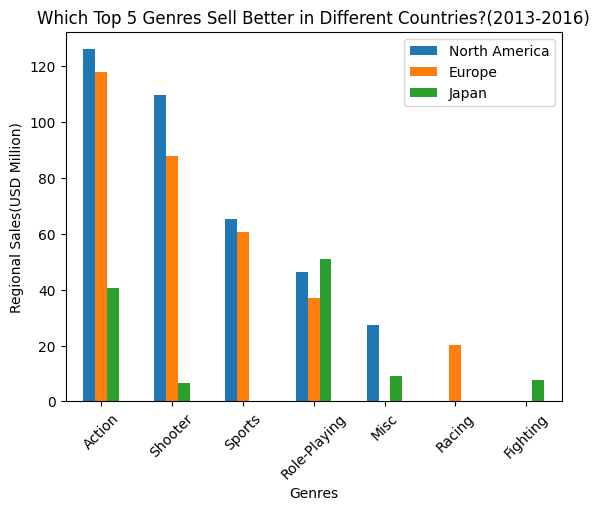

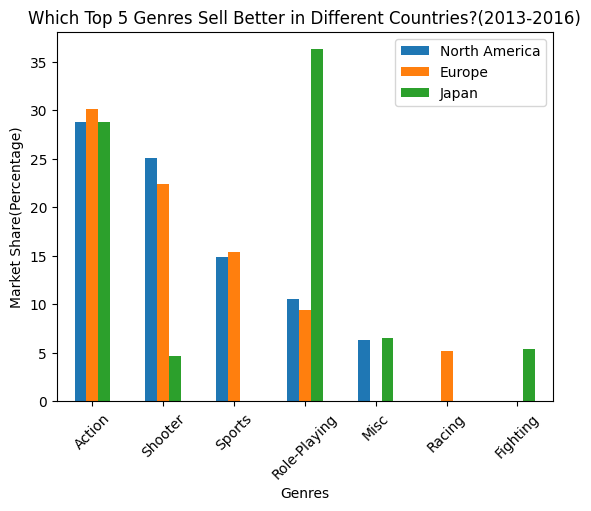

In [ ]:
# Create a comparative genre analysis
na_genre_table = genre_region_sales('NA')
eu_genre_table = genre_region_sales('EU')
jp_genre_table = genre_region_sales('JP')


regional_genre_data = na_genre_table.merge(eu_genre_table, on='genre', how='outer')

regional_genre_data = regional_genre_data.merge(jp_genre_table, on='genre', how='outer')

print(regional_genre_data)


regional_genre_data.plot(kind='bar',
                   y=['na_market_share', 'eu_market_share', 'jp_market_share'],
                   x= 'genre',
                xlabel='Genres',
                ylabel='Market Share(Percentage)',
                rot=45,
                title='Which Top 5 Genres Sell Better in Different Countries?(2013-2016)',
               )
plt.legend(['North America', 'Europe', 'Japan'])
plt.show()

regional_genre_data.plot(kind='bar',

                   y=['na_sales', 'eu_sales', 'jp_sales'],
                   x= 'genre',
                xlabel='Genres',
                ylabel='Regional Sales(USD Million)',
                rot=45,
                title='Which Top 5 Genres Sell Better in Different Countries?(2013-2016)',
               )
plt.legend(['North America', 'Europe', 'Japan'])
plt.show()






North America and Europe show to have very similar genre prefernces enjoying Action, Shooter,and Sports games. While Japan prefers Role-playing followed by Action games more than any other.

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [ ]:
# Function to analyze ESRB rating impact
region_name = 'North America','NA', 'Europe', 'EU', 'Japan', 'JP'
def rating_region_sales(region_name):
    if region_name == 'North America' or region_name == 'NA':
        na_total_sales = games_relevant.groupby('rating').agg({
            'na_sales':'sum'
        })
        print (na_total_sales)

    elif region_name == 'Europe' or region_name == 'EU':
        eu_total_sales = games_relevant.groupby('rating').agg({
            'eu_sales':'sum'
        })
        print (eu_total_sales)

    elif region_name == 'Japan' or region_name == 'JP':
        jp_total_sales = games_relevant.groupby('rating').agg({
            'jp_sales':'sum'
        })
        print (jp_total_sales)
    else:
        return ('No Data For that Region')


print('North America Platform Sales:')
print(rating_region_sales('NA'))

print('Europe Platform Sales:')
print(rating_region_sales('EU'))

print('Japan Platform Sales:')
print(rating_region_sales('JP'))

North America Platform Sales:
        na_sales
rating          
E          79.05
E10+       54.24
M         165.21
T          49.79
None
Europe Platform Sales:
        eu_sales
rating          
E          83.36
E10+       42.69
M         145.32
T          41.95
None
Japan Platform Sales:
        jp_sales
rating          
E          15.14
E10+        5.89
M          14.11
T          20.59
None


        na_sales  eu_sales  jp_sales
rating                              
E          79.05     83.36     15.14
E10+       54.24     42.69      5.89
M         165.21    145.32     14.11
T          49.79     41.95     20.59
        na_sales  eu_sales  jp_sales
rating                              
E          79.05     83.36     15.14
E10+       54.24     42.69      5.89
M         165.21    145.32     14.11
T          49.79     41.95     20.59


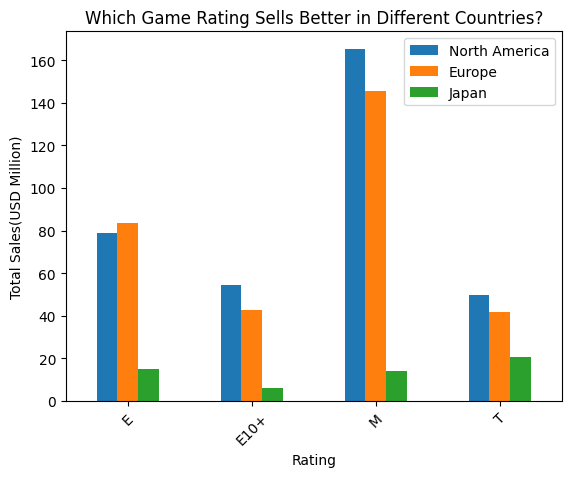

In [ ]:
# Analyze ESRB impact for each region
rating_region_total_sales = games_relevant.groupby('rating').agg({
            'na_sales':'sum',
            'eu_sales':'sum',
            'jp_sales':'sum'
        })
print (rating_region_total_sales)

top_rating = ['E', 'E10+', 'M', 'T']
region_top_rating = rating_region_total_sales.loc[top_rating]
print(region_top_rating)



region_top_rating.plot(kind='bar',
                xlabel='Rating',
                ylabel='Total Sales(USD Million)',
                rot=45,
                title='Which Game Rating Sells Better in Different Countries?',
               )
plt.legend(['North America', 'Europe', 'Japan'])
plt.show()

Once again, the North America and Europe trends are very similar as they enjoy M and E rated games. While Japan prefers T rated Games.

# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The hypothesis testing section is harder to follow because the template’s dedicated Step 5 code cell is left empty and the work starts later. Consider moving (or duplicating) the hypothesis test code into the intended Step 5 area so the section reads as a single, complete unit.

</div>


**Hypothesis Setup:**

• H₀ (Null Hypothesis): μ_XOne User Ratings = μ_PC User Rating (mean user ratings are equal), I want to find if a difference exists.

• H₁ (Alternative Hypothesis): μ_XOne User Ratings ≠ μ_PC User Rating (mean user ratings. are different)  

• Significance Level: α = 0.05, does not have a life-threatening risk-related industry.

• Test Choice: Welch's t-test (unequal variances assumed). The test samples are independent of each other, and when tested, their variances are not equal. I am also running a 2-tailed test to assess for any difference.

• Assumptions: Approximately normal distributions

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

After stating the decision (“can’t reject H0”), add one sentence interpreting it in context: what this does (and does not) imply about evidence of a difference in average user ratings between Xbox One and PC at your chosen alpha.

</div>


In [ ]:

# Test the hypotheses
user_score__platform_games_relevant = games_relevant.groupby(['platform','name']).agg({
    'user_score':'mean'
}).reset_index().dropna()
print(user_score__platform_games_relevant)


array1 = user_score__platform_games_relevant[user_score__platform_games_relevant['platform'] == 'XOne']['user_score']
array2 = user_score__platform_games_relevant[user_score__platform_games_relevant['platform'] == 'PC']['user_score']
alpha = 0.05

results = st.ttest_ind(array1, array2, equal_var=False)

print('p-value', results.pvalue)
if results.pvalue < alpha:
    print("We Reject the Null Hypothesis")
else:
    print("We Can't Reject the Null Hypothesis")



     platform                                               name  user_score
7         3DS                           7th Dragon III Code: VFD         8.2
13        3DS  Adventure Time: The Secret of the Nameless Kin...         5.6
18        3DS                              Angry Birds Star Wars         3.0
19        3DS               Animal Crossing: Happy Home Designer         6.9
22        3DS                Attack on Titan: Humanity in Chains         4.5
...       ...                                                ...         ...
2226     XOne                         Wolfenstein: The Old Blood         8.0
2227     XOne                                         Worms: WMD         8.1
2228     XOne                                             XCOM 2         8.1
2230     XOne                                Zombie Army Trilogy         7.2
2232     XOne                         Zumba Fitness: World Party         6.2

[1192 rows x 3 columns]
p-value 0.14759594013430324
We Can't Reject the Nul

We cant prove that the XOne and PC User Scores are statistically different. This means that sometimes they are the same but sometimes they are not and there is not a clear trend or correlation here.

**Hypothesis Setup:**

• H₀ (Null Hypothesis): μ_Action User Ratings = μ_Sports User Ratings (mean User Ratings are equal), I want to find if a difference exists.

• H₁ (Alternative Hypothesis): μ_Action User Ratings ≠ μ_Sports User Ratings(mean User Ratings are different)  

• Significance Level: α = 0.05, does not have a life-threatening risk-related industry.

• Test Choice: Welch's t-test (unequal variances assumed). The test samples are independent of each other, and when tested, their variances are not equal. I am also running a 2-tailed test to assess for any difference.

• Assumptions: Approximately normal distributions

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Add a brief written conclusion for the Action vs Sports test (in addition to the p-value/decision): explain what rejecting H0 implies about the average user ratings, referencing your alpha and the direction/meaning of the result.

</div>


In [ ]:
# Test the hypotheses
user_score_games_relevant = games_relevant.groupby(['genre','name']).agg({
    'user_score':'mean'
}).reset_index().dropna()
print(user_score_games_relevant)


array1 = user_score_games_relevant[user_score_games_relevant['genre'] == 'Action']['user_score']
array2 = user_score_games_relevant[user_score_games_relevant['genre'] == 'Sports']['user_score']
alpha = 0.05

results = st.ttest_ind(array1, array2, equal_var=False)

print('p-value', results.pvalue)
if results.pvalue < alpha:
    print("We Reject the Null Hypothesis")
else:
    print("We Can't Reject the Null Hypothesis")


         genre                                               name  user_score
1       Action                                      7 Days to Die    5.550000
6       Action  Adventure Time: The Secret of the Nameless Kin...    6.550000
7       Action                 Aegis of Earth: Protonovus Assault    8.050000
12      Action                           Anima - Gate of Memories    7.900000
14      Action                     Arslan: The Warriors of Legend    6.200000
...        ...                                                ...         ...
1257  Strategy                                  Total War: Attila    7.300000
1258  Strategy                                 Total War: Rome II    4.200000
1259  Strategy                               Total War: WARHAMMER    7.300000
1261  Strategy                              War for the Overworld    7.700000
1262  Strategy                                             XCOM 2    7.733333

[579 rows x 3 columns]
p-value 6.67553632872251e-09
We Reject t

By rejecting the Null Hypothesis our findings are stating that the Action and Sport Genre mean user scores are statistically different and that it is not just a fluke that they are different this time. Another way of saying this is that users do not feel the same about Sport and Action Genre games.

# Step 6. Write a general conclusion


I have been able to identify several trends that are important to look out for, as we search for big winners this upcoming year and plan advertising campaigns. We should be focusing on the newer consoles that have been released, currently being the PS4 and XBox One. Companies are releasing new consoles roughly every 5-7 years so keep an eye out for a new nintendo console that may be released this year or the following year. The best genre for games are shooter, action, sports, and roleplaying. SHooter and sports are much more consistent in their sales while action can be very boom or bust. That being said action and shooter games have the highest earning potential and make up the highest market share. We want to mainly focus our resources on North America and Europe as they contribute the most to our sales and they have similar game tastes so we wont waste money or time developing different advertisment campaigns. That Campaign would be mainly focused around PS4 M rated Shooter games that could be sold cross platform to the Xbox One. Almost all of the time and money we spend on advertising to Japan though, should be focused on handheld Consoles, such as the 3ds and PSV, and Roleplaying games as their sales skew very heavily to those platforms and genre.